In [7]:
%pip install --upgrade pip -q
%pip install scipy -q
%pip install pycountry -q
%pip install seaborn -q
%pip install numpy -q
%pip install plotly -q
%pip install python-dotenv -q
%pip install neo4j -q
%pip install pyarrow fastparquet -q
%pip install nbformat -q
%pip install pycountry_convert -q
%pip install country-converter -q
#%pip install py2neo networkx -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import IPython

# restart python kernel
IPython.Application.instance().kernel.do_shutdown(restart=True)

{'status': 'ok', 'restart': True}

: 

## Preamble

In [24]:
from datetime import datetime
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from scipy import stats
import plotly.express as px
from dotenv import load_dotenv
import seaborn as sns
import pycountry
import country_converter
from pycountry_convert import map_country_alpha3_to_country_alpha2, country_alpha2_to_continent_code, convert_continent_code_to_continent_name

from neo4j import GraphDatabase

# visualization of the graph here
#import networkx as nx
#from py2neo import Graph
#from IPython.display import HTML, display
#import json

In [2]:
start_date = datetime(2025, 7, 11)

## Loading aggregated data

Run the download_data.sh script first.  

## RQ1 DMARC adoption on cctld level

In [77]:
input_path = f"../data/oi-warehouse/testing/source=tranco/cctld_dmarc/year={start_date.year}/month={start_date.month:02d}/day={start_date.day:02d}"

cctld_dmarc_pdf = pd.read_parquet(input_path)
print(cctld_dmarc_pdf.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164388 entries, 0 to 164387
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   tld          164388 non-null  object
 1   query_name   164388 non-null  object
 2   apex_domain  164080 non-null  object
 3   p            163387 non-null  object
 4   sp           35749 non-null   object
 5   aspf         34010 non-null   object
 6   adkim        28467 non-null   object
 7   rua_domains  164388 non-null  object
 8   ruf_domains  164388 non-null  object
 9   is_gov       164388 non-null  bool  
dtypes: bool(1), object(9)
memory usage: 11.4+ MB
None


In [78]:
def is_policy_strict(p, sp):
    if p in ['none', 'invalid', None]:  # None (null) is no policy at all! which is different than 'none'
        return False
    if sp in ['none', 'invalid']:
        return False
    return True


cctld_dmarc_pdf['is_policy_strict'] = cctld_dmarc_pdf[["p", "sp"]].apply(lambda x: is_policy_strict(x.iloc[0], x.iloc[1]), axis=1)
display(cctld_dmarc_pdf.head(5))

,tld,query_name,apex_domain,p,sp,aspf,adkim,rua_domains,ruf_domains,is_gov,is_policy_strict
0,gov.za,_dmarc.parliament.gov.za.,parliament.gov.za,none,None,None,None,[rep.dmarcanalyzer.com],[for.dmarcanalyzer.com],True,False
1,cc,_dmarc.deeplex.cc.,deeplex.cc,none,None,None,None,[],[],False,False
2,cc,_dmarc.risenyating.cc.,risenyating.cc,reject,reject,s,s,[],[],False,True
3,cr,_dmarc.bunkr.cr.,bunkr.cr,quarantine,None,None,None,[],[],False,True
4,us,_dmarc.awsdns-us-gov-60.us.,awsdns-us-gov-60.us,reject,None,None,None,[dmarc.amazon.com],[dmarc.amazon.com],False,True


In [79]:
def get_country_from_tld(tld):
    if tld:
        x = tld
        if 'gov' == tld:
            return 'USA'
        if 'gov' in tld:
            x = tld.split('.')[-1]
        if x == 'scot':
            x = 'uk'
        if pycountry.countries.get(alpha_2=x):
            return pycountry.countries.get(alpha_2=x).alpha_3
        return country_converter.convert(x)  # cover 'uk' domains for example
    return None


def get_aggr_policy_count_per_country(cctld_dmarc_pdf):
    # Count policies per country (TLD)
    policy_counts_pdf = cctld_dmarc_pdf.groupby('tld')['is_policy_strict'].agg([
        ('strict_policies', 'sum'),  # Count of True values
        ('relaxed_policies', lambda x: (~x).sum())  # Count of False values
    ]).reset_index()

    # Rename 'tld' to 'country' for clarity
    #policy_counts_pdf.rename(columns={'tld': 'country'}, inplace=True)

    # 'country' (3-letter ISO codes), 'strict_policies', 'relaxed_policies'
    policy_counts_pdf["country"] = policy_counts_pdf["tld"].apply(lambda x: get_country_from_tld(x))

    print("wrongly assigned countries:")  # e.g. country_converter.convert('gov') == 'not found'
    print(len(policy_counts_pdf[(policy_counts_pdf["country"].isna()) | (policy_counts_pdf["country"] == "not found") | (policy_counts_pdf["country"] == "")]))

    # Aggregate by country to handle cases like USA having both 'gov' and 'us' TLDs
    policy_counts_pdf = policy_counts_pdf.groupby('country').agg({
        'strict_policies': 'sum',
        'relaxed_policies': 'sum'
    }).reset_index()

    # Calculate ratio (handling division by zero)
    policy_counts_pdf['difference'] = policy_counts_pdf['strict_policies'] - policy_counts_pdf['relaxed_policies']
    # if relaxed policy is 0, then there will be a div by zero error... just assign 1 to those
    policy_counts_pdf['ratio'] = np.where(policy_counts_pdf['relaxed_policies'] == 0,
        policy_counts_pdf['strict_policies'],  # When denominator is 0, return numerator
        policy_counts_pdf['strict_policies'] / policy_counts_pdf['relaxed_policies']  # Otherwise divide normally
    )
    policy_counts_pdf['total_policies'] = policy_counts_pdf['strict_policies'] + policy_counts_pdf['relaxed_policies']

    return policy_counts_pdf

policy_counts_pdf = get_aggr_policy_count_per_country(cctld_dmarc_pdf.copy())

wrongly assigned countries:
0


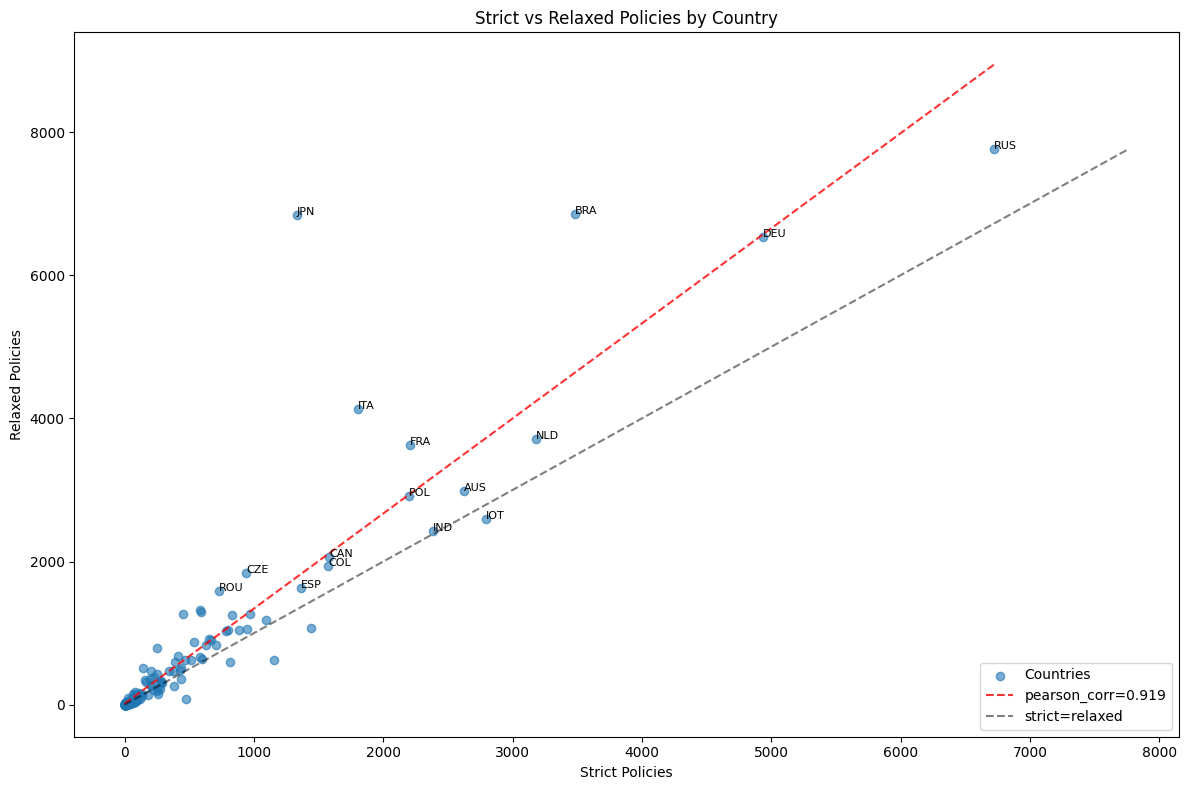

In [80]:
def strict_relaxed_policy_correlation(policy_counts_pdf, threshold):

    plt.figure(figsize=(12, 8))
    plt.scatter(policy_counts_pdf['strict_policies'], policy_counts_pdf['relaxed_policies'], alpha=0.6, label='Countries')

    # Calculate Pearson correlation
    pearson_r, p_value = stats.pearsonr(policy_counts_pdf['strict_policies'], 
                                        policy_counts_pdf['relaxed_policies'])

    # Calculate regression line
    z = np.polyfit(policy_counts_pdf['strict_policies'], 
                policy_counts_pdf['relaxed_policies'], 1)
    p = np.poly1d(z)

    # Plot regression line
    x_line = np.linspace(policy_counts_pdf['strict_policies'].min(), 
                        policy_counts_pdf['strict_policies'].max(), 1000)
    plt.plot(x_line, p(x_line), "r--", alpha=0.8, 
            label=f'pearson_corr={pearson_r:.3f}')

    # Add x=y reference line
    max_val = max(policy_counts_pdf['strict_policies'].max(), 
                  policy_counts_pdf['relaxed_policies'].max())
    min_val = min(policy_counts_pdf['strict_policies'].min(), 
                  policy_counts_pdf['relaxed_policies'].min())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, 
            label='strict=relaxed')

    # Add labels for interesting points (optional)
    for idx, row in policy_counts_pdf.iterrows():
        if row['strict_policies'] > threshold or row['relaxed_policies'] > threshold:
            plt.annotate(row['country'], (row['strict_policies'], row['relaxed_policies']), fontsize=8)

    # Add legend with Pearson correlation in bottom right
    #legend_text = f'Pearson r = {pearson_r:.3f} (p = {p_value:.3f})'
    plt.legend(loc='lower right') #, title=legend_text, title_fontsize=12)

    plt.xlabel('Strict Policies')
    plt.ylabel('Relaxed Policies')
    plt.title('Strict vs Relaxed Policies by Country')
    plt.tight_layout()
    plt.show()

strict_relaxed_policy_correlation(policy_counts_pdf.copy(), threshold=1500)

This view is from tranco, hence it may change from CT logs measurements.

The correlation means that the more domains adopt DMARC, they are likely having similar strict and relaxed policies in place. The plot shows a few countries with more strict DMARC policy, for example IOT (.io -- British Indian Ocean Territory) with a large DMARC adoption and with more strict ones. A few notable cases: France, Italy, Japan and Brazil with large DMARC adoption but with more relaxed policies. This graph is an indication of adoption first, enforcement later.

how does this change over time? are the countries moving from relaxed to strict policy?

Caveat: strictness per nr of domains ratio. Some domains have higher absolute counts which could bias the visualization.

ATF (0.83) - total: 12
COK (1.00) - total: 2
GBR (0.86) - total: 548
GLP (0.86) - total: 14
GMB (1.00) - total: 2
GRL (0.90) - total: 20
KNA (1.00) - total: 1
NER (0.83) - total: 12
NRU (1.00) - total: 2
TCD (1.00) - total: 3
WLF (1.00) - total: 2
YEM (1.00) - total: 1


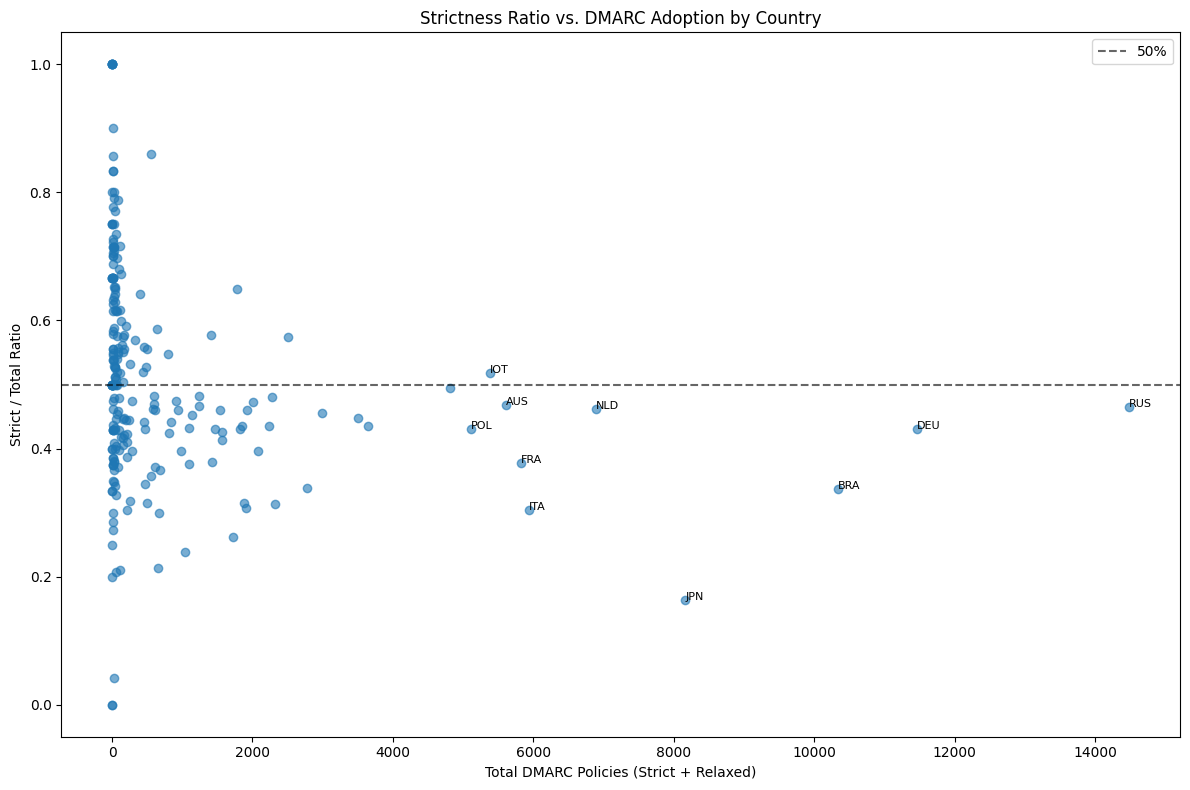

In [81]:
def strict_policy_correlation_ratio(policy_counts_pdf, threshold):
    policy_counts_pdf['total_policies'] = (
        policy_counts_pdf['strict_policies'] + policy_counts_pdf['relaxed_policies']
    )
    policy_counts_pdf['strict_ratio'] = (
        policy_counts_pdf['strict_policies'] / policy_counts_pdf['total_policies']
    )

    plt.figure(figsize=(12, 8))
    plt.scatter(policy_counts_pdf['total_policies'], 
                policy_counts_pdf['strict_ratio'], alpha=0.6)

    # Annotate major countries
    for idx, row in policy_counts_pdf.iterrows():
        if row['total_policies'] > threshold:  # same threshold you already use
            plt.annotate(row['country'], (row['total_policies'], row['strict_ratio']), fontsize=8)
        if row['strict_ratio'] > 0.8:
            print(f"{row['country']} ({row['strict_ratio']:.2f}) - total: {row['total_policies']}")

    plt.axhline(0.5, color='k', linestyle='--', alpha=0.6, label="50%")
    plt.xlabel("Total DMARC Policies (Strict + Relaxed)")
    plt.ylabel("Strict / Total Ratio")
    plt.title("Strictness Ratio vs. DMARC Adoption by Country")
    plt.legend()
    plt.tight_layout()
    plt.show()

strict_policy_correlation_ratio(policy_counts_pdf.copy(), threshold=5000)

High adoption doesn’t mean high strictness (e.g., Japan);
High strictness ratios usually come with low adoption;
Australia, Netherlands, Germany and Russia with a more balanced adoption.

IOT (.io) is a corner case because the domain name have usage due to its double meaning name in computer science.

Even countries with low adoption do a slow start with DMARC.

Smaller domain spaces where coordination is easier.

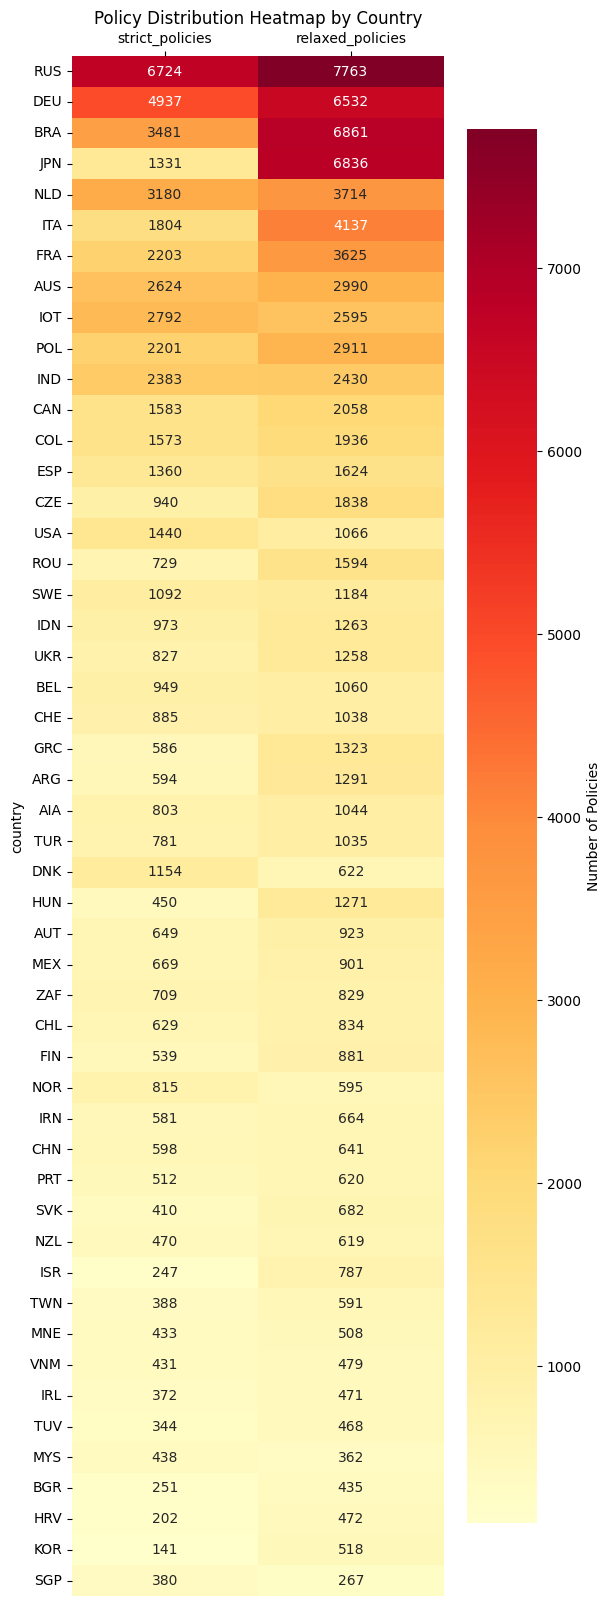

In [82]:
def policy_distribution_heatmap(policy_counts_pdf):
    # Reshape data for heatmap
    policy_counts_pdf['total_policies'] = (
        policy_counts_pdf['strict_policies'] + policy_counts_pdf['relaxed_policies']
    )
    # sorting by total:
    policy_counts_pdf = policy_counts_pdf.sort_values(by='total_policies', ascending=False)
    heatmap_data = policy_counts_pdf.set_index('country')[['strict_policies', 'relaxed_policies']]

    # Create heatmap (show top 50 for readability)
    plt.figure(figsize=(6, 20))
    sns.heatmap(heatmap_data.head(50), 
                annot=True, 
                fmt='d', 
                cmap='YlOrRd',
                cbar_kws={'label': 'Number of Policies'})
    
    plt.title('Policy Distribution Heatmap by Country')
    plt.yticks(rotation=0)
    plt.gca().xaxis.tick_top()  # Move x-axis labels to top
    plt.gca().xaxis.set_label_position('top')  # Move x-axis label to top
    plt.show()

policy_distribution_heatmap(policy_counts_pdf.copy())

Low presence of US domains: the domains might be registered under .com, .net or .org TLDs for historical reasons.  

the most unbalanced is japan.

Most mature adopters (5,000+ policies) converge to:  
Russia: 46% strict.  
Germany: 43% strict.  
Brazil: 34% strict.  
Netherlands: 46% strict.  

the concentration of DMARC usage is in EU.

This 35-45% range appears to be the equilibrium for large-scale deployments, with Japan being the dramatic outlier at 16%.

In [83]:
def convert_alpha3_to_continent_code(alpha3: str):
    if alpha3 == "VAT":
        return "Europe"
    if alpha3 == 'ATF':
        return 'Antarctica'
    if alpha3 == 'TLS':
        return 'Asia'
    if alpha3 == 'PCN':
        return 'Oceania'
    if alpha3 == 'SXM':
        return 'North America'
    return convert_continent_code_to_continent_name(country_alpha2_to_continent_code(map_country_alpha3_to_country_alpha2()[alpha3.upper()]))

# Top X represents 80% of total policies
def most_dmarc_users(policy_counts_pdf):
    policy_counts_pdf['total_policies'] = (
        policy_counts_pdf['strict_policies'] + policy_counts_pdf['relaxed_policies']
    )
    policy_counts_pdf = policy_counts_pdf.sort_values(by='total_policies', ascending=False)  # Largest first
    policy_counts_pdf["cdf"] = policy_counts_pdf['total_policies'].cumsum() / policy_counts_pdf['total_policies'].sum()

    # If you want to include the first country that pushes it over 80%:
    # Find the index where we cross 80%
    idx_80 = (policy_counts_pdf["cdf"] > 0.8).idxmax()
    top_80_percent_inclusive = policy_counts_pdf.loc[:idx_80]
    display(top_80_percent_inclusive[['country', 'strict_policies', 'relaxed_policies', 'total_policies']])

    print(f"Number of countries representing 80% of DMARC adoption: {len(top_80_percent_inclusive)}")
    print(f"These {len(top_80_percent_inclusive)} countries out of {len(policy_counts_pdf)} total countries represent 80% of global DMARC adoption")

    policy_counts_pdf.loc[:, 'continent'] = policy_counts_pdf['country'].apply(lambda x: convert_alpha3_to_continent_code(x))
    # groupby continent
    display(
        policy_counts_pdf.groupby('continent')[['strict_policies', 'relaxed_policies', 'total_policies']].sum().sort_values(by='total_policies', ascending=False)
    )


most_dmarc_users(policy_counts_pdf.copy())

,country,strict_policies,relaxed_policies,total_policies
174,RUS,6724,7763,14487
54,DEU,4937,6532,11469
29,BRA,3481,6861,10342
103,JPN,1331,6836,8167
152,NLD,3180,3714,6894
99,ITA,1804,4137,5941
67,FRA,2203,3625,5828
13,AUS,2624,2990,5614
93,IOT,2792,2595,5387
165,POL,2201,2911,5112


Number of countries representing 80% of DMARC adoption: 34
These 34 countries out of 232 total countries represent 80% of global DMARC adoption


,strict_policies,relaxed_policies,total_policies
continent,,,
Europe,36752,49778,86530
Asia,14591,21640,36231
South America,7124,11747,18871
North America,5164,5503,10667
Oceania,3773,4488,8261
Africa,1720,2096,3816
Antarctica,10,2,12


In [ ]:
# https://www.iban.com/country-codes
# South Sudan (.ss; SSD) cannot be displayed in the world graph

def world_plot_ratio(copy_policy_counts_pdf):
    # Calculate percentage of strict policies for hover info
    copy_policy_counts_pdf['pct_strict'] = (copy_policy_counts_pdf['strict_policies'] / copy_policy_counts_pdf['total_policies']) * 100

    # Create the choropleth map
    fig = px.choropleth(copy_policy_counts_pdf,
                        locations='country',  # Your 3-letter country codes
                        locationmode='ISO-3',
                        color='ratio',
                        hover_name='country',
                        hover_data={
                            'strict_policies': ':,',
                            'relaxed_policies': ':,',
                            'total_policies': ':,',
                            'pct_strict': ':.1f',
                            'ratio': ':.2f'
                        },
                        color_continuous_scale='RdBu_r',  # Red for high ratio (more strict), Blue for low
                        labels={
                            'ratio': 'Strict/Relaxed Ratio',
                            'strict_policies': 'Strict Policies',
                            'relaxed_policies': 'Relaxed Policies',
                            'total_policies': 'Total Policies',
                            'pct_strict': '% Strict'
                        },
                        title='DMARC Policy Strictness Ratio by Country')

    # Update layout for better visualization
    fig.update_layout(
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='natural earth'
        ),
        coloraxis_colorbar=dict(
            title="Strict/Relaxed<br>Ratio",
            tickmode='linear',
            tick0=0,
            dtick=0.5,
            len=0.7,
            thickness=15
        ),
        height=700,
        title={
            'text': 'DMARC Policy Strictness Ratio by Country',
            'x': 0.5,
            'xanchor': 'center',
            'font': {'size': 20}
        }
    )

    # Customize hover template
    fig.update_traces(
        hovertemplate='<b>%{hovertext}</b><br>' +
                    'Strict Policies: %{customdata[0]}<br>' +
                    'Relaxed Policies: %{customdata[1]}<br>' +
                    'Total Policies: %{customdata[2]}<br>' +
                    'Percent Strict: %{customdata[3]:.1f}%<br>' +
                    'Ratio: %{customdata[4]:.2f}<extra></extra>'
    )

    fig.show()

def world_plot_differences(copy_policy_counts_pdf):
    # Use the 3-letter ISO codes for the map
    fig2 = px.choropleth(copy_policy_counts_pdf,
                                locations='country',
                                locationmode='ISO-3',
                                color='difference',
                                hover_name='country',
                                hover_data={
                                    'strict_policies': ':,',
                                    'relaxed_policies': ':,',
                                    'difference': ':,'
                                },
                                color_continuous_scale='RdBu_r',
                                color_continuous_midpoint=0,
                                range_color=[copy_policy_counts_pdf['difference'].min(),
                                            copy_policy_counts_pdf['difference'].max()],
                                labels={'difference': 'Policy Difference'},
                                title='DMARC Policy Difference by Country (Red=More Strict, Blue=More Relaxed)')

    fig2.update_layout(
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='natural earth'
        ),
        height=700,
    )

    fig2.show()

def world_plot_ratio_categories(copy_policy_counts_pdf):
    # Optional: Create intervals for categorical coloring
    highest_ratio = copy_policy_counts_pdf['ratio'].max()
    l = 'strict/relaxed policy ratio categories'

    intervals = [0.0, 0.5, 1.0, 2.0, highest_ratio]

    # Define the category labels in the order you want them
    category_labels = [
        f'Mostly Relaxed ({intervals[0]}:{intervals[1]}]',
        f'Balanced-Relaxed ({intervals[1]}:{intervals[2]}]',
        f'Balanced-Strict ({intervals[2]}:{intervals[3]}]',
        f'Mostly Strict ({intervals[3]}:{intervals[4]}]'
    ]

    copy_policy_counts_pdf[l] = pd.cut(copy_policy_counts_pdf['ratio'],
                                            bins=intervals,
                                            labels=category_labels)

    fig3 = px.choropleth(copy_policy_counts_pdf,
                        locations='country',
                        locationmode='ISO-3',
                        color=l,
                        hover_name='country',
                        hover_data={
                            'strict_policies': ':,',
                            'relaxed_policies': ':,',
                            'ratio': ':.2f'
                        },
                        color_discrete_map={
                            category_labels[0]: '#2166ac',
                            category_labels[1]: '#92c5de', 
                            category_labels[2]: '#f4a582',
                            category_labels[3]: '#b2182b'  # Use the dynamic label
                        },
                        category_orders={l: category_labels},
                        title='DMARC Policy Categories by Country')

    fig3.update_layout(
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='natural earth'
        ),
        height=700,
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=-0.1,
            xanchor='center',
            x=0.5
        )
    )

    fig3.show()

def world_plot_percentage(copy_policy_counts_pdf):
    # Calculate the percentage of strict and relaxed policies
    copy_policy_counts_pdf['strict_percentage'] = (copy_policy_counts_pdf['strict_policies'] / copy_policy_counts_pdf['total_policies']) * 100
    copy_policy_counts_pdf['relaxed_percentage'] = (copy_policy_counts_pdf['relaxed_policies'] / copy_policy_counts_pdf['total_policies']) * 100

    fig4 = px.choropleth(copy_policy_counts_pdf,
                        locations='country',
                        locationmode='ISO-3',
                        color='strict_percentage',
                        hover_name='country',
                        hover_data={
                            'strict_policies': ':,',
                            'relaxed_policies': ':,',
                            'strict_percentage': ':.2f',
                            'relaxed_percentage': ':.2f'
                        },
                        color_continuous_scale='RdBu_r',
                        color_continuous_midpoint=0,
                        range_color=[copy_policy_counts_pdf['strict_percentage'].min(),
                                    copy_policy_counts_pdf['strict_percentage'].max()],
                        labels={'strict_percentage': 'Strict Policy Percentage'},
                        title='DMARC Strict Policy Percentage by Country')

    fig4.update_layout(
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='natural earth'
        ),
        height=700,
    )

    fig4.show()

world_plot_percentage(policy_counts_pdf.copy())
world_plot_ratio_categories(policy_counts_pdf.copy())
#world_plot_ratio(policy_counts_pdf.copy())
#world_plot_differences(policy_counts_pdf.copy())

many digitally advanced nations (Germany, Japan, Brazil, UK) have mostly relaxed policies, while some less digitally prominent nations show strict policies.  

South Africa has a higher adoption in Africa
Asia has as few big users of DMARC like Japan, with high adoption but more on the relaxed policy.  
Countries with more strict DMARC policies also are also with less DMARC adoption.  


In [86]:
# Summary statistics
def print_statistics(policy_counts_pdf):
    print("\n=== DMARC Policy Ratio Statistics ===")
    print(f"Countries with more strict than relaxed (ratio > 1): {(policy_counts_pdf['ratio'] > 1).sum()}")
    print(f"Countries with more relaxed than strict (ratio <= 1): {(policy_counts_pdf['ratio'] <= 1).sum()}")
    print(f"\nMean ratio: {policy_counts_pdf['ratio'].mean():.2f}")

    print(f"\nTop 5 strictest countries (by ratio):")
    print(policy_counts_pdf.nlargest(5, 'ratio')[['country', 'ratio', 'strict_policies', 'relaxed_policies']])

    print(f"\nTop 5 most relaxed countries (by ratio):")
    print(policy_counts_pdf.nsmallest(5, 'ratio')[['country', 'ratio', 'strict_policies', 'relaxed_policies']])

print_statistics(policy_counts_pdf)


=== DMARC Policy Ratio Statistics ===
Countries with more strict than relaxed (ratio > 1): 102
Countries with more relaxed than strict (ratio <= 1): 130

Mean ratio: 1.29

Top 5 strictest countries (by ratio):
    country     ratio  strict_policies  relaxed_policies
81      GRL  9.000000               18                 2
71      GBR  6.116883              471                77
77      GLP  6.000000               12                 2
11      ATF  5.000000               10                 2
147     NER  5.000000               10                 2

Top 5 most relaxed countries (by ratio):
    country     ratio  strict_policies  relaxed_policies
0       ABW  0.000000                0                 3
189     SSD  0.000000                0                 2
219     VAT  0.043478                1                23
103     JPN  0.194705             1331              6836
16      BDI  0.250000                1                 4


### government domains

In [87]:
gov_cctld_dmarc_pdf = cctld_dmarc_pdf[cctld_dmarc_pdf['tld'].str.contains('gov')]

In [90]:
gov_policy_counts_pdf = get_aggr_policy_count_per_country(gov_cctld_dmarc_pdf.copy())

wrongly assigned countries:
0


Distribution of government domains

In [137]:
# statistics of how many gov domain with respect to all domains per country, ordered by total gov domains of each country
def show_gov_per_country(cctld_dmarc_pdf):
    b = cctld_dmarc_pdf.groupby(['tld', "is_gov"]).size().reset_index(name='count')
    b["country"] = b["tld"].apply(lambda x: get_country_from_tld(x))
    country_breakdown = b.groupby(['country', 'is_gov'])['count'].sum().reset_index()
    #country_breakdown["country"] = country_breakdown["country"].apply(lambda x: get_country_from_tld(x))

    # Pivot to get government and non-government columns
    country_pivot = country_breakdown.pivot(index='country', columns='is_gov', values='count').fillna(0)

    # Rename columns for clarity
    country_pivot.columns = ['non_gov_count', 'gov_count']

    # Calculate total domains per country
    country_pivot['total_count'] = country_pivot['non_gov_count'] + country_pivot['gov_count']

    # Calculate percentages
    country_pivot['gov_percentage'] = (country_pivot['gov_count'] / country_pivot['total_count'] * 100).round(2)
    country_pivot['non_gov_percentage'] = (country_pivot['non_gov_count'] / country_pivot['total_count'] * 100).round(2)

    # Reset index to make country a regular column
    country_pivot = country_pivot.reset_index()

    # Sort by government percentage in descending order
    country_pivot = country_pivot.sort_values('gov_percentage', ascending=False)
    display(country_pivot[["country", "gov_count", "gov_percentage", "total_count"]].head(20))

show_gov_per_country(cctld_dmarc_pdf.copy())

,country,gov_count,gov_percentage,total_count
71,GBR,548.0,100.00,548.0
189,SSD,2.0,100.00,2.0
76,GIN,2.0,66.67,3.0
217,USA,1417.0,56.54,2506.0
30,BRB,3.0,50.00,6.0
32,BTN,9.0,50.00,18.0
114,LBR,1.0,50.00,2.0
157,OMN,23.0,43.40,53.0
31,BRN,6.0,37.50,16.0
123,MAC,8.0,36.36,22.0


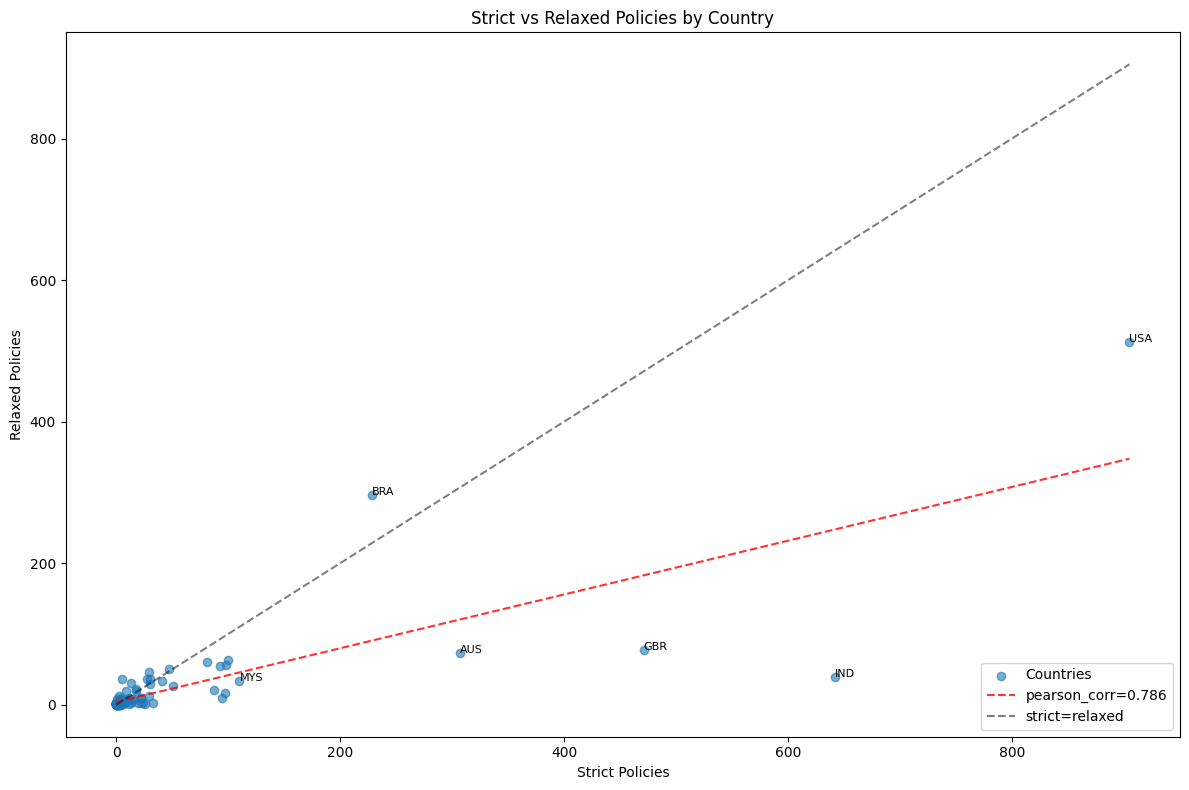

In [138]:
strict_relaxed_policy_correlation(gov_policy_counts_pdf.copy(), threshold=100)

AUS (0.81) - total: 380
AZE (0.94) - total: 35
BHS (1.00) - total: 2
BIH (0.86) - total: 7
BLR (0.88) - total: 25
BLZ (1.00) - total: 2
BWA (1.00) - total: 1
FJI (1.00) - total: 2
GBR (0.86) - total: 548
HKG (0.91) - total: 103
IND (0.94) - total: 681
IRN (0.81) - total: 16
JOR (0.92) - total: 26
LVA (0.96) - total: 27
MNE (1.00) - total: 1
MNG (0.92) - total: 12
NAM (1.00) - total: 1
NLD (1.00) - total: 1
QAT (0.86) - total: 22
SAU (0.81) - total: 108
SDN (1.00) - total: 1
SGP (0.85) - total: 114
SHN (1.00) - total: 1
SYR (1.00) - total: 1
TKM (1.00) - total: 4
TUN (1.00) - total: 2


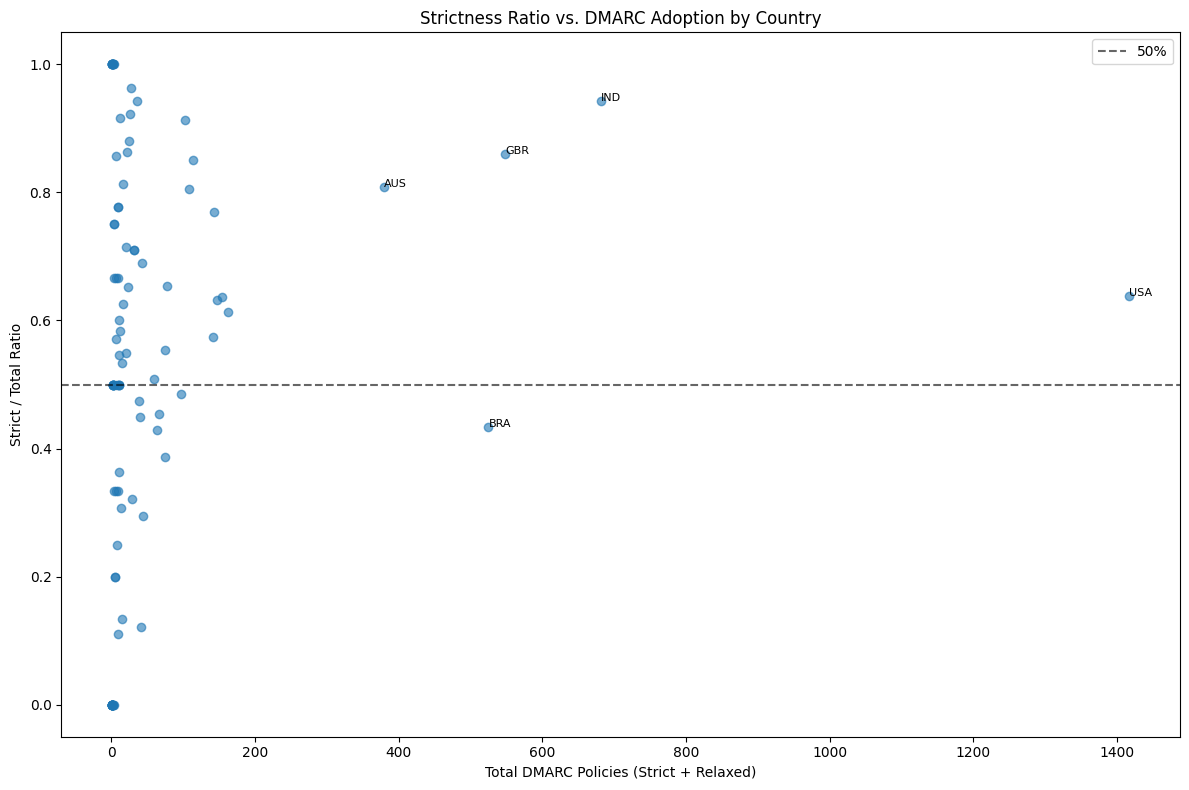

In [139]:
strict_policy_correlation_ratio(gov_policy_counts_pdf.copy(), threshold=200)

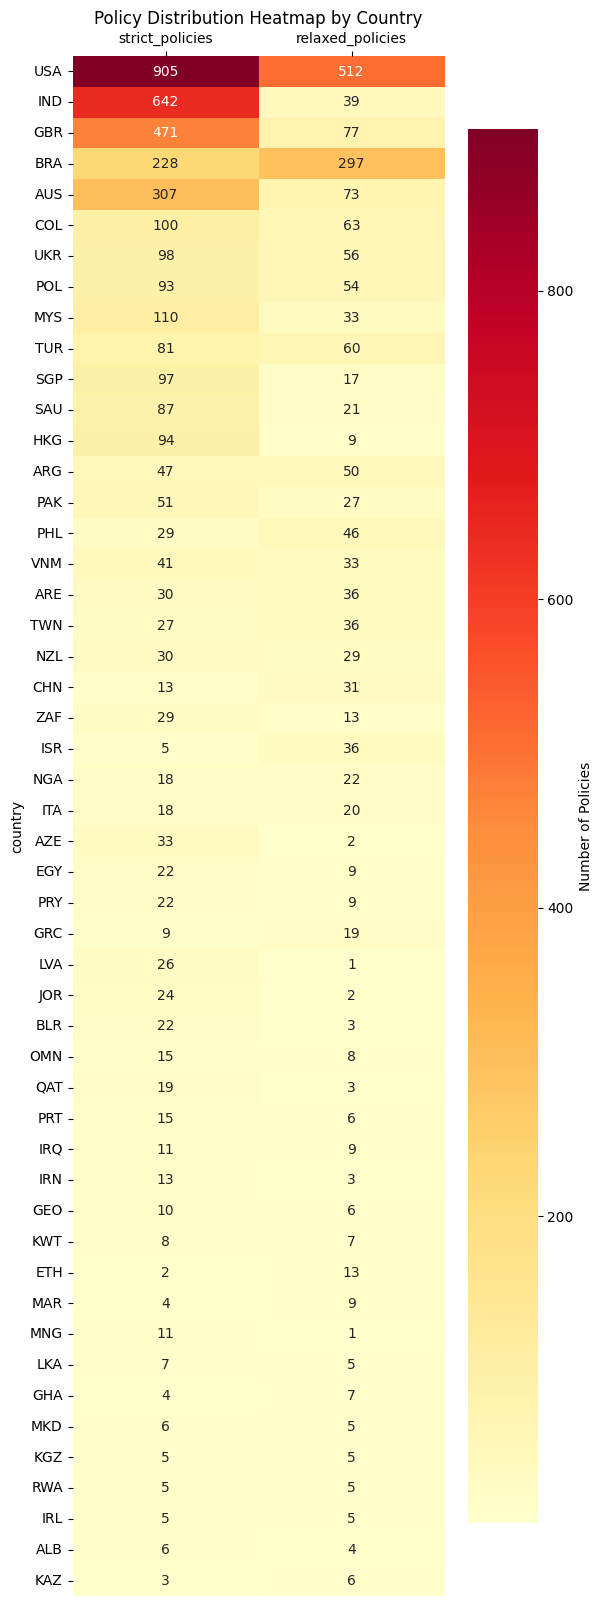

In [140]:
policy_distribution_heatmap(gov_policy_counts_pdf.copy())

In [141]:
most_dmarc_users(gov_policy_counts_pdf.copy())

,country,strict_policies,relaxed_policies,total_policies
96,USA,905,512,1417
38,IND,642,39,681
30,GBR,471,77,548
13,BRA,228,297,525
5,AUS,307,73,380
21,COL,100,63,163
95,UKR,98,56,154
73,POL,93,54,147
65,MYS,110,33,143
93,TUR,81,60,141


Number of countries representing 80% of DMARC adoption: 15
These 15 countries out of 101 total countries represent 80% of global DMARC adoption


,strict_policies,relaxed_policies,total_policies
continent,,,
Asia,1500,508,2008
North America,916,519,1435
Europe,778,263,1041
South America,401,421,822
Oceania,339,103,442
Africa,105,105,210


In [142]:
world_plot_percentage(gov_policy_counts_pdf.copy())
world_plot_ratio_categories(gov_policy_counts_pdf.copy())

In [143]:
print_statistics(gov_policy_counts_pdf.copy())


=== DMARC Policy Ratio Statistics ===
Countries with more strict than relaxed (ratio > 1): 47
Countries with more relaxed than strict (ratio <= 1): 54

Mean ratio: 2.30

Top 5 strictest countries (by ratio):
   country      ratio  strict_policies  relaxed_policies
53     LVA  26.000000               26                 1
6      AZE  16.500000               33                 2
38     IND  16.461538              642                39
44     JOR  12.000000               24                 2
61     MNG  11.000000               11                 1

Top 5 most relaxed countries (by ratio):
   country  ratio  strict_policies  relaxed_policies
1      AGO    0.0                0                 1
7      BFA    0.0                0                 1
20     CMR    0.0                0                 3
23     DMA    0.0                0                 1
27     EST    0.0                0                 1


## Graph Analysis

### Neo4j connection

In [6]:
class Neo4jConnection:
    def __init__(self, uri, user, password):
        self.uri = uri
        self.user = user
        self.password = password
        self.driver = None

    def __enter__(self):
        """Enter the context manager - establish connection"""
        self.driver = GraphDatabase.driver(self.uri, auth=(self.user, self.password))
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        """Exit the context manager - close connection"""
        if self.driver:
            self.driver.close()

    def test_connection(self):
        with self.driver.session() as session:
            result = session.run("RETURN 'Connection successful' as message")
            print(result.single()["message"])

    def query(self, query, parameters=None):
        if not self.driver:
            raise RuntimeError("Connection not established. Use within 'with' statement.")

        with self.driver.session() as session:
            result = session.run(query, parameters)
            return [record.data() for record in result]

    def query_to_df(self, query, parameters=None):
        results = self.query(query, parameters)
        return pd.DataFrame(results)

    def write_query(self, query, parameters=None):
        if not self.driver:
            raise RuntimeError("Connection not established. Use within 'with' statement.")

        with self.driver.session() as session:
            result = session.run(query, parameters)
            return result.consume().counters

load_dotenv()
NEO4J_PASSWD = os.getenv('NEO4J_PASSWD')
if not NEO4J_PASSWD:
    raise ValueError("NEO4J_PASSWD not found in environment variables")

URI = "bolt://localhost:7687"
AUTH = ("neo4j", NEO4J_PASSWD)

Warning! RUN THIS ONLY ONCE TO SET UP THE DATABASE

In [34]:
with Neo4jConnection(URI, *AUTH) as conn:
    conn.test_connection()
    conn.write_query("CREATE INDEX vertices_id_index IF NOT EXISTS FOR (n:Vertices) ON (n.id)")
    conn.write_query("""
        CALL () {
            LOAD CSV WITH HEADERS FROM "file:///vertices.csv" AS row
            CREATE (:Vertices {id: row.id, is_gov: row.is_gov})
        } IN TRANSACTIONS OF 5000 ROWS
    """)
    result = conn.query("MATCH (n:Vertices) RETURN count(n) as total_vertices")
    print(f"Total vertices in database: {result[0]['total_vertices']}")

    result_rua = conn.write_query("""
        CALL () {
            LOAD CSV WITH HEADERS FROM "file:///edges.csv" AS row
            WITH row WHERE row.edge_type = "rua"
            MATCH (source:Vertices {id: row.src})
            MATCH (destination:Vertices {id: row.dst})
            MERGE (source)-[:rua]->(destination)
        } IN TRANSACTIONS OF 5000 ROWS
    """)
    print(f"rua edges created: {result_rua.relationships_created}")

    result_ruf = conn.write_query("""
        CALL () {
            LOAD CSV WITH HEADERS FROM "file:///edges.csv" AS row
            WITH row WHERE row.edge_type = "ruf"
            MATCH (source:Vertices {id: row.src})
            MATCH (destination:Vertices {id: row.dst})
            MERGE (source)-[:ruf]->(destination)
        } IN TRANSACTIONS OF 5000 ROWS
    """)
    print(f"ruf edges created: {result_ruf.relationships_created}")

    # tranco, no cctld filter
    #Total vertices in database: 439947
    #rua edges created: 315274
    #ruf edges created: 158219

Connection successful
Total vertices in database: 170993
rua edges created: 117716
ruf edges created: 58346


below will clean up the database... be careful!

In [33]:
def nodes_in_database(conn):
    result = conn.query("""
        MATCH (n)
        RETURN count(n) AS node_count
    """)
    print(f"Total nodes in database: {result[0]['node_count']}")
    result = conn.query("""
        MATCH ()-[r]-()
        RETURN count(r) AS relationship_count
    """)
    print(f"Total relationships in database: {result[0]['relationship_count']}")

# cleaning up the database
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    conn.test_connection()
    print("before the clean up")
    nodes_in_database(conn)

    try:
        conn.query("""
            CALL gds.graph.drop('DMARC')
        """)
    except Exception as e:
        print(f"Error dropping graph: {e}")

    conn.query("""
        MATCH ()-[r]-()
        DELETE r;
    """)

    conn.query("""
        MATCH (n)
        DELETE n;
    """)

    print("after the clean up")
    nodes_in_database(conn)


Connection successful
before the clean up
Total nodes in database: 171031
Total relationships in database: 273237
Error dropping graph: {code: Neo.ClientError.Procedure.ProcedureCallFailed} {message: Failed to invoke procedure `gds.graph.drop`: Caused by: org.neo4j.gds.core.loading.GraphNotFoundException: Graph with name `DMARC` does not exist on database `neo4j`. It might exist on another database.}
after the clean up
Total nodes in database: 0
Total relationships in database: 0


Best visualized at cypher using:  

MATCH (n:Vertices)-[r]-(m:Vertices)  
RETURN n, r, m  
LIMIT 50;  


Visualize individual nodes:  

MATCH (n:Vertices)-[r]-(m:Vertices)  
WHERE n.id = "bibleminute.co"  
RETURN n, r, m  

##### Local visualization -- not good

In [ ]:
def visualize_with_existing_connection(conn, query, limit=50):
    # Get data using your existing connection
    data = conn.query(f"{query} LIMIT {limit}")

    # Create NetworkX graph
    G = nx.DiGraph()  # Directed graph for rua/ruf relationships

    # Process the data
    for record in data:
        if 'source' in record and 'target' in record:
            G.add_edge(record['source'], record['target'], 
                      rel_type=record.get('relationship', 'CONNECTED'))

    # Visualization
    plt.figure(figsize=(15, 10))
    pos = nx.spring_layout(G, k=2, iterations=50)

    # Different colors for different relationship types
    edge_colors = []
    for u, v, d in G.edges(data=True):
        if d.get('rel_type') == 'rua':
            edge_colors.append('red')
        elif d.get('rel_type') == 'ruf':
            edge_colors.append('blue')
        else:
            edge_colors.append('gray')

    # Draw the graph
    nx.draw_networkx_nodes(G, pos, node_color='lightgreen', 
                          node_size=300, alpha=0.8)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, 
                          arrows=True, arrowsize=20, alpha=0.6)
    nx.draw_networkx_labels(G, pos, font_size=6, font_weight='bold')

    plt.title(f"Graph Visualization ({len(G.nodes())} nodes, {len(G.edges())} edges)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Print stats
    print(f"Nodes: {len(G.nodes())}")
    print(f"Edges: {len(G.edges())}")

    return G

# horrible visualization; no other better python choice... use cypher which is better
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    # Query that returns source, target, relationship
    query = """
        MATCH (n:Vertices)-[r]->(m:Vertices)
        RETURN n.id as source, m.id as target, type(r) as relationship
    """

    graph = visualize_with_existing_connection(conn, query, limit=50)

### Connected Components algorithm

In [35]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    current_graphs = conn.query("""
        CALL gds.graph.list()
        YIELD graphName, nodeCount, relationshipCount
        RETURN graphName, nodeCount, relationshipCount
        ORDER BY graphName
    """)

    if current_graphs:
        print("Current graph projections:")
        for graph in current_graphs:
            print(f"  {graph['graphName']}: {graph['nodeCount']} nodes, {graph['relationshipCount']} relationships")
        if False: # delete graph!
            for graph in current_graphs:
                conn.write_query(f"CALL gds.graph.drop({graph['graphName']}) YIELD graphName;")
                print(f"Dropped existing graph projection {graph['graphName']}.")
    else:
        conn.write_query("""
            CALL gds.graph.project(
                'DMARC',
                'Vertices',
                ['rua', 'ruf']
            )
        """)

#  DMARC: 439947 nodes, 473493 relationships


In [36]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    result_pdf = conn.query_to_df("""
        CALL gds.wcc.stream('DMARC', {relationshipTypes: ['rua', 'ruf']})
        YIELD nodeId, componentId
        RETURN  componentId, 
                collect(gds.util.asNode(nodeId).id) AS node_ids,
                size(collect(gds.util.asNode(nodeId).id)) AS component_size
        ORDER BY size(node_ids) DESC
        LIMIT 10;
    """)
    display(result_pdf)

,componentId,node_ids,component_size
0,5,"[ballast-nedam.nl, saib.com.sa, companymobile....",46760
1,2668,"[idera.com, youtube.com.eg, google.td, google....",461
2,5650,"[millevertus.ca, dressageanival.ca, bijouterie...",168
3,3417,"[nabytkomanie.cz, permaseminka.cz, essenseurop...",142
4,3541,"[f-b.no, aasanetidende.no, gd.no, hardanger-fo...",91
5,1645,"[dmarc.microsoft, aka.ms, sharepoint.de, offic...",85
6,3188,"[bmw-motorrad.de, mini.fi, mini.com.mx, bmw.ca...",79
7,5440,"[iib.gov.in, bharatpetroleum.in, mothercare.in...",70
8,11734,"[pausetoujours.fr, actu-economique.fr, objecti...",64
9,4013,"[va.se, dagenssamhalle.se, vlt.se, dalademokra...",60


In [51]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    clusters_pdf = conn.query_to_df("""
        CALL gds.wcc.stream('DMARC', {relationshipTypes: ['rua', 'ruf']})
        YIELD nodeId, componentId
        WITH componentId, collect(gds.util.asNode(nodeId).id) AS node_ids
        WHERE size(node_ids) > 1  // Only multi-node components

        // For each component, get top n most connected nodes
        UNWIND node_ids AS node_id
        MATCH (target:Vertices {id: node_id})
        OPTIONAL MATCH (source:Vertices)-[r:rua|ruf]->(target)
        WHERE source.id IN node_ids
        WITH componentId, node_ids, target.id AS vertex_id, count(r) AS incoming_count
        ORDER BY componentId, incoming_count DESC

        // Get top 5 nodes per component
        //WITH componentId, node_ids, collect({vertex: vertex_id, incoming: incoming_count})[0..5] AS top_nodes
        WITH componentId, node_ids, collect({vertex: vertex_id, incoming: incoming_count}) AS top_nodes

        RETURN componentId,
            size(node_ids) AS component_size,
            top_nodes
        ORDER BY component_size DESC
        //LIMIT 10;
    """)
    display(clusters_pdf)

,componentId,component_size,top_nodes
0,5,46760,"[{'incoming': 6790, 'vertex': 'proofpoint.com'..."
1,2668,461,"[{'incoming': 459, 'vertex': 'google.com'}, {'..."
2,5650,168,"[{'incoming': 168, 'vertex': 'votresite.ca'}, ..."
3,3417,142,"[{'incoming': 284, 'vertex': 'leadhub.co'}, {'..."
4,3541,91,"[{'incoming': 91, 'vertex': 'amedia.no'}, {'in..."
...,...,...,...
8417,161404,2,"[{'incoming': 4, 'vertex': 'sevenkeys.com.br'}..."
8418,161776,2,"[{'incoming': 1, 'vertex': 'verkaufen.ch'}, {'..."
8419,162550,2,"[{'incoming': 1, 'vertex': 'singleinterface.co..."
8420,166734,2,"[{'incoming': 2, 'vertex': 'gibilogic.com'}, {..."


In [ ]:
# row 6 is tripadvisor
display(clusters_pdf["top_nodes"].iloc[5])

[{'incoming': 143, 'vertex': 'tripadvisor.com'},
 {'incoming': 0, 'vertex': 'housetrip.com'},
 {'incoming': 0, 'vertex': 'flipkey.com'},
 {'incoming': 0, 'vertex': 'tripadvisor.co.kr'},
 {'incoming': 0, 'vertex': 'tripadvisor.ca'},
 {'incoming': 0, 'vertex': 'cruisecritic.com.au'},
 {'incoming': 0, 'vertex': 'tripadvisor.cn'},
 {'incoming': 0, 'vertex': 'viatorsystems.com'},
 {'incoming': 0, 'vertex': 'tripadvisor.cl'},
 {'incoming': 0, 'vertex': 'cruisecritic.co.uk'},
 {'incoming': 0, 'vertex': 'thefork.it'},
 {'incoming': 0, 'vertex': 'tripadvisor.jp'},
 {'incoming': 0, 'vertex': 'tripadvisor.com.eg'},
 {'incoming': 0, 'vertex': 'tripadvisor.com.vn'},
 {'incoming': 0, 'vertex': 'tripadvisor.at'},
 {'incoming': 0, 'vertex': 'tripadvisor.com.tr'},
 {'incoming': 0, 'vertex': 'thefork.nl'},
 {'incoming': 0, 'vertex': 'tripadvisor.de'},
 {'incoming': 0, 'vertex': 'tripadvisorsupport.com'},
 {'incoming': 0, 'vertex': 'tripadvisor.com.sg'},
 {'incoming': 0, 'vertex': 'tripadvisor.sk'},
 {'i

In [82]:
display(clusters_pdf["top_nodes"].iloc[2])

[{'incoming': 216, 'vertex': 'bmwgroup.com'},
 {'incoming': 0, 'vertex': 'bmw.hu'},
 {'incoming': 0, 'vertex': 'alphabet.pl'},
 {'incoming': 0, 'vertex': 'mini.es'},
 {'incoming': 0, 'vertex': 'mini.my'},
 {'incoming': 0, 'vertex': 'mini.co.kr'},
 {'incoming': 0, 'vertex': 'bmwlat.com'},
 {'incoming': 0, 'vertex': 'mini.dk'},
 {'incoming': 0, 'vertex': 'bmw-motorrad.fr'},
 {'incoming': 0, 'vertex': 'bmw.be'},
 {'incoming': 0, 'vertex': 'mini.de'},
 {'incoming': 0, 'vertex': 'bmw.lu'},
 {'incoming': 0, 'vertex': 'bmw-welt.com'},
 {'incoming': 0, 'vertex': 'bmwgroupfs.com'},
 {'incoming': 0, 'vertex': 'bmw.no'},
 {'incoming': 0, 'vertex': 'bmw-motorrad.es'},
 {'incoming': 0, 'vertex': 'bmw.in'},
 {'incoming': 0, 'vertex': 'mini.no'},
 {'incoming': 0, 'vertex': 'bmw.ca'},
 {'incoming': 0, 'vertex': 'bmw-motorrad.de'},
 {'incoming': 0, 'vertex': 'bmw.ch'},
 {'incoming': 0, 'vertex': 'mini.com'},
 {'incoming': 0, 'vertex': 'mini.in'},
 {'incoming': 0, 'vertex': 'bmwgroupdesignworks.com'},
 

Visualization of specific components

// First, get the node IDs for component 2  
CALL gds.wcc.stream('DMARC', {relationshipTypes: ['rua', 'ruf']})  
YIELD nodeId, componentId  
WHERE componentId = 2  
WITH collect(gds.util.asNode(nodeId).id) AS component_nodes  

// Then visualize those nodes and their relationships  
MATCH (n:Vertices)  
WHERE n.id IN component_nodes  
MATCH (n)-[r:rua|ruf]-(m:Vertices)  
WHERE m.id IN component_nodes  
RETURN n, r, m;  

What are the small clusters?  
Business relationships: subsidiaries sending dmarc report to their holding's mailbox.

If you own multiple domains, it makes sense that all rua and ruf reports are sent to the IT security mailbox, either the holding company, the regional domain or to a 3rd party processor. For instance, regional tripadvisor such as tripadvisor.be send reports to its main region tripadvisor.com. Also, housetrip.com seems a subsidiary of tripadvisor, which also send dmarc reports to tripadvisor.com. The holding company doesn't use any specialized mail security company, and hence, handles the reports in-house.

Although in this example the companies are under the group, they may be in different countries and hence, different data jurisdictions apply.

The "holding", where the reports are sent, can turn into a target because it concentrates information

Can we distinguish subsidiaries and holdings automatically? maybe only using a web crawler...

Are the small clusters sending the report to the same data protection law?

#### Strongly Connected Components

"finds sets of connected nodes in a directed graph where each node is reachable in both directions from any other node in the same set"

In [ ]:
with Neo4jConnection(URI, *AUTH) as conn:
    scc_pdf = conn.query_to_df("""
        CALL gds.scc.stream("DMARC", {relationshipTypes: ['rua', 'ruf']})
        YIELD nodeId, componentId
        WITH componentId, count(nodeId) AS component_size
        RETURN component_size AS ComponentSize, count(*) AS NumberOfComponentsWithThisSize
        ORDER BY ComponentSize DESC
    """)
    display(scc_pdf)

    scc_pdf = conn.query_to_df("""
        CALL gds.scc.stream("DMARC", {relationshipTypes: ['rua', 'ruf']})
        YIELD nodeId, componentId
        RETURN componentId, collect(gds.util.asNode(nodeId).id) AS domains
        ORDER BY size(domains) DESC
        LIMIT 20
    """)
    display(scc_pdf)

,ComponentSize,NumberOfComponentsWithThisSize
0,2,17
1,1,439913


,componentId,domains
0,129612,"[birtema.com, temadam.com]"
1,30221,"[ciwf.org, ciwf.org.uk]"
2,62656,"[lukfook.com, jw28.com]"
3,106764,"[metalmarket.eu, metalmarket.eu]"
4,253374,"[peoplefluent.com, peopleclick.com]"
5,412070,"[bit.ly, bitly.net]"
6,24883,"[nuc.co.kr, kuvings.com]"
7,59742,"[kbtg.tech, kasikornbank.com]"
8,101337,"[netservicesgroup.net, netservicesgroup.com]"
9,352522,"[jetmailx.com.br, tavola.com.br]"


Only 17 cases have a 2 domain components that are strongly connected, ie, can reach each other (point to each other). All the other domains are not strongly connected. But we can find communities in them by looking at (weakly) connected components.

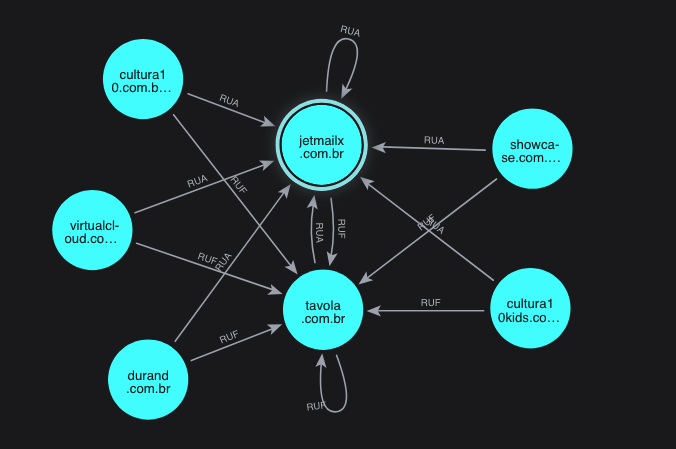

### Degree Centrality algorithm

"The degree centrality measures the number of incoming or outgoing (or both) relationships from a node, which can be defined by the orientation of a relationship projection. If a projection contains directed relationships, only outgoing relationships of a node are counted (the out-degree)." -- https://neo4j.com/docs/graph-data-science/current/algorithms/degree-centrality/  


In [52]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    # this is calculating the outdegree centrality, ie the top 10 domains that send rua/ruf reports to most distinct domains
    print("Calculating degree centrality using out-degree...")
    outdegree_pdf = conn.query_to_df("""
        CALL gds.degree.stream('DMARC')
        YIELD nodeId, score
        RETURN gds.util.asNode(nodeId).id AS domains, score AS nr_outgoing_links
        ORDER BY nr_outgoing_links DESC, domains DESC
        LIMIT 10;
    """)
    display(outdegree_pdf)

    print("Calculating degree centrality using in-degree...")
    indegree_pdf = conn.query_to_df("""
        CALL gds.degree.stream('DMARC', { orientation: 'REVERSE' })
        YIELD nodeId, score
        RETURN gds.util.asNode(nodeId).id AS domains, score AS nr_incoming_links
        ORDER BY nr_incoming_links DESC, domains DESC
        LIMIT 10;
    """)
    display(indegree_pdf)

Calculating degree centrality using out-degree...


,domains,nr_outgoing_links
0,minsa.gob.pe,7.0
1,mim.gov.sa,7.0
2,ikea.com.sa,7.0
3,geld.nl,7.0
4,y.co,6.0
5,wordans.ca,6.0
6,wits.ac.za,6.0
7,vvsg.be,6.0
8,vuurenrook.nl,6.0
9,vaxjo.se,6.0


Calculating degree centrality using in-degree...


,domains,nr_incoming_links
0,proofpoint.com,6790.0
1,dmarc-reports.cloudflare.net,6488.0
2,vali.email,4687.0
3,dmarcanalyzer.com,3796.0
4,dmarcian.com,3614.0
5,brevo.com,3277.0
6,dmarcadvisor.com,2993.0
7,mailinblue.com,2798.0
8,dmarc-report.com,2378.0
9,postmarkapp.com,2105.0


In [53]:
def add_external_domains_to_pdf(row, src_column, dst_column):
    """Add a column to the DataFrame indicating if the outgoing links are to external domains."""
    src_domain = row[src_column]
    dst_domains = set(row[dst_column])
    row['external_domains'] = []
    for dst_domain in dst_domains:
        # Check if the destination domain is external
        if not dst_domain.endswith(src_domain):
            row['external_domains'] = row.get('external_domains', []) + [dst_domain]

    row['nr_external_domains'] = len(row['external_domains'])
    return row


with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    domains_outdegree_pdf = conn.query_to_df("""
        MATCH (n:Vertices)
        OPTIONAL MATCH (n)-[:rua|ruf]->(connected)
        WITH n, collect(connected.id) AS outgoing_link_ids, count(connected) AS nr_outgoing_links
        RETURN n.id AS domains, nr_outgoing_links, outgoing_link_ids
        ORDER BY nr_outgoing_links DESC, domains DESC
        LIMIT 200
    """)
    # display(domains_outdegree_pdf)

domains_outdegree_pdf = domains_outdegree_pdf.apply(add_external_domains_to_pdf, axis=1, args=('domains', 'outgoing_link_ids'))
display(domains_outdegree_pdf)

,domains,nr_outgoing_links,outgoing_link_ids,external_domains,nr_external_domains
0,minsa.gob.pe,7,"[minsa.gob.pe, dmarcian.com, vali.email, vali....","[easydmarc.com, dmarcian.com, vali.email]",3
1,mim.gov.sa,7,"[deem.sa, mim.gov.sa, nic.gov.sa, dmarc.gov.sa...","[dmarc.gov.sa, nic.gov.sa, deem.sa]",3
2,ikea.com.sa,7,"[ikea.com.sa, ikea.com, webklipper.com, webkli...","[ikea.com, webklipper.com, cisco.com]",3
3,geld.nl,7,"[ondmarc.com, geld.nl, mailgun.org, mailgun.or...","[ondmarc.com, smtpeter.com, mailgun.org]",3
4,y.co,6,"[dmarc-report.com, y.co, everest.email, everes...","[dmarc-report.com, everest.email]",2
...,...,...,...,...,...
195,prerender.io,5,"[dmarcinput.com, saas.group, saas.group, dmarc...","[saas.group, dmarcinput.com, dmarcdigests.com]",3
196,prepodavame.bg,5,"[easydmarc.eu, zaednovchas.bg, zaednovchas.bg,...","[zaednovchas.bg, vali.email, easydmarc.eu]",3
197,premierenergy.ro,5,"[premierenergy.ro, easydmarc.eu, dmarc-reports...","[vali.email, dmarc-reports.cloudflare.net, eas...",3
198,portsaid.com.ar,5,"[retailrocket.net, mailinblue.com, portsaid.co...","[mailinblue.com, retailrocket.net]",2


In [79]:
print(
    domains_outdegree_pdf['domains'].iloc[0], domains_outdegree_pdf['external_domains'].iloc[0],
    '\n',
    domains_outdegree_pdf['domains'].iloc[1], domains_outdegree_pdf['external_domains'].iloc[1],
    '\n',
    domains_outdegree_pdf['domains'].iloc[2], domains_outdegree_pdf['external_domains'].iloc[2],
    '\n',
    domains_outdegree_pdf['domains'].iloc[99], domains_outdegree_pdf['external_domains'].iloc[99]
)

bibleminute.co ['dmarcian.com', '250ok.net', 'radiantdigital.com', 'dmarc-report.com'] 
 baymack.com ['dmarcian.com', 'easydmarc.asia', 'dmarc-reports.cloudflare.net', 'mailgun.org', 'ondmarc.com', 'dmarc-report.com'] 
 wespire.com ['glockapps.com', 'easydmarc.us', 'dmarcinput.com', 'uriports.com'] 
 ripc.gov.sa ['dmarc-report.com', 'dmarc.gov.sa']


Why one domain would send the report to multiple mailboxes?  
To send copies of reports to different parties. For example, you can send to a mailbox of your own domain, to a mailbox of an external domain, e.g., the holder company (in case the source domain is a subsidiary company), and send to a company specialized in processing DMARC reports such as DMARCian. One example is bibleminute.co, which is a subsidiary of radiantdigital.com, which sends report to its "holding" and to different email specialized companies.

Sending to multiple specialized companies seems more a configuration mistake.
One can think of distributing the reports to avoid single point of failures (should the primary DMARC processing company mailbox reject to receive the report due to size). But adding more companies to process reports increase costs, add overhead to the source domain that requested outsourcing of processing reports because it will have to manage multiple advises from different dmarc report processing companies Or worse, request to send (in rua/ruf tags) inappropriate reports may spam the mailboxes of those receiving dmarc reports~\cite{dmarc_rfc}.

#### Where the links go?

In [55]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    self_reporting_pdf = conn.query_to_df("""
        // Vertices pointing to themselves
        MATCH (n:Vertices)-[r:rua|ruf]->(n)
        RETURN n.id AS domain, "self-loop" AS reason
        UNION
        // Vertices with no outgoing edges
        MATCH (n:Vertices)
        WHERE NOT (n)-[:rua|ruf]->()
        RETURN n.id AS domain, "no-outgoing" AS reason
    """)

    display(self_reporting_pdf)

,domain,reason
0,ausl.mo.it,self-loop
1,intermax.nl,self-loop
2,smsmasivos.com.ar,self-loop
3,ont.io,self-loop
4,bp.org.br,self-loop
...,...,...
116762,acehosting.ca,no-outgoing
116763,realmmlp.ca,no-outgoing
116764,xinamaga.ro,no-outgoing
116765,morion.ua,no-outgoing


In [ ]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    one_external_domain_pdf = conn.query_to_df("""
        MATCH (n:Vertices)-[r:rua|ruf]->(m:Vertices)
        WHERE n <> m
        AND NOT exists((n)-[:rua|ruf]->(n))  // No self-loops
        WITH n, count(r) AS edge_count
        WHERE edge_count = 1
        RETURN n.id AS domain
    """)

display(one_external_domain_pdf)

,domain
0,valtori.fi
1,seenthis.se
2,ternium.com.mx
3,kpnmail.nl
4,gmx.fr
...,...
25973,kwo.ch
25974,myrepublic.com.sg
25975,vmcdn.ca
25976,edelweisslife.in


In [48]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    two_or_more_external_domain_pdf = conn.query_to_df("""
        MATCH (n:Vertices)-[r:rua|ruf]->(m:Vertices)
        WHERE n <> m
        AND NOT exists((n)-[:rua|ruf]->(n))  // Exclude vertices with self-loops
        WITH n, count(r) AS edge_count
        WHERE edge_count >= 2
        RETURN n.id AS domain
    """)

display(two_or_more_external_domain_pdf)
#Percent of domains with 2 or more external domains: 3.7%

,domain
0,nickscali.co.nz
1,plush.com.au
2,autorambler.ru
3,rambler.ru
4,ro.ru
...,...
28243,privetmir.ru
28244,decn.co.jp
28245,waiwai-net.ne.jp
28246,ces-net.jp


In [56]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    total = conn.query_to_df("""
        MATCH (n:Vertices)
        RETURN count(n) AS total
    """)['total'].iloc[0]

individual_sum = len(two_or_more_external_domain_pdf) + len(one_external_domain_pdf) + len(self_reporting_pdf)
assert total == individual_sum, f"Total count mismatch. Total={total}, individual sum={individual_sum}"
# put this into a pandas df
summary_df = pd.DataFrame({
    "2 or more external domains": [
        len(two_or_more_external_domain_pdf) / total * 100,
        len(two_or_more_external_domain_pdf)
    ],
    "1 external domain": [
        len(one_external_domain_pdf) / total * 100,
        len(one_external_domain_pdf)
    ],
    "No external domains": [
        len(self_reporting_pdf) / total * 100,
        len(self_reporting_pdf)
    ],
    "All": [100, total],
})
# transpose column and rows
summary_df = summary_df.T
summary_df.columns = ['Percent', 'Count']
summary_df.index.name = 'Category'
summary_df.reset_index(inplace=True)
display(summary_df)

,Category,Percent,Count
0,2 or more external domains,16.519975,28248.0
1,1 external domain,15.192435,25978.0
2,No external domains,68.287591,116767.0
3,All,100.000000,170993.0


how many of the out-links are to external domains?

how many of the out-links are to other countries?

## RQ2 DMARC reporting on cctld level

what do I want:  

show top report receivers per country.  
show the cases where reporting is going to an external country but belongs to the same company group.  
show the % of external domains per country (world map) -- real external.  


In [63]:
cctld_dmarc_pdf

,tld,query_name,apex_domain,p,sp,aspf,adkim,rua_domains,ruf_domains,is_policy_strict
0,kr,_dmarc.0db.co.kr.,0db.co.kr,none,None,None,None,[],[],False
1,fm,_dmarc.1.fm.,1.fm,quarantine,None,None,None,[],[],True
2,at,_dmarc.1000things.at.,1000things.at,quarantine,None,None,None,[1000things.at],[1000things.at],True
3,by,_dmarc.10gkb.by.,10gkb.by,reject,None,s,None,[],[],True
4,nl,_dmarc.112brabant.nl.,112brabant.nl,none,None,None,None,[],[],False
...,...,...,...,...,...,...,...,...,...,...
164383,pl,_dmarc.zary.pl.,zary.pl,reject,None,s,s,[zary.pl],[],True
164384,nz,_dmarc.zebrano.co.nz.,zebrano.co.nz,none,none,r,r,[zebrano.co.nz],[zebrano.co.nz],False
164385,io,_dmarc.zelus.io.,zelus.io,none,None,None,None,[zelus.io],[],False
164386,ae,_dmarc.zhic.ae.,zhic.ae,none,None,None,None,[],[],False


## RQZ

In [ ]:
aggr_rua_pdf = pd.read_parquet("../data/oi-warehouse/aggregation/what=rua_addresses/").rename(columns={"sum(count)": "count"})
aggr_ruf_pdf = pd.read_parquet("../data/oi-warehouse/aggregation/what=ruf_addresses/").rename(columns={"sum(count)": "count"})

aggr_rua_pdf["rua_apex_domain"] = aggr_rua_pdf['rua_apex_domain'] = aggr_rua_pdf['rua_apex_domain'].replace({None: 'Invalid', np.nan: 'Invalid'})
aggr_ruf_pdf["ruf_apex_domain"] = aggr_ruf_pdf['ruf_apex_domain'] = aggr_ruf_pdf['ruf_apex_domain'].replace({None: 'Invalid', np.nan: 'Invalid'})

aggr_rua_ruf_pdf = pd.concat([
    aggr_rua_pdf.rename(columns={"rua_apex_domain": "rua_ruf_apex_domain"}), 
    aggr_ruf_pdf.rename(columns={"ruf_apex_domain": "rua_ruf_apex_domain"})
], ignore_index=True).drop(columns=["source", "year", "month", "day"]
).groupby("rua_ruf_apex_domain", as_index=False).agg(count=("count", "sum")
).sort_values("count", ascending=False)
aggr_rua_ruf_pdf["percent"] = aggr_rua_ruf_pdf["count"] / aggr_rua_ruf_pdf["count"].sum() * 100

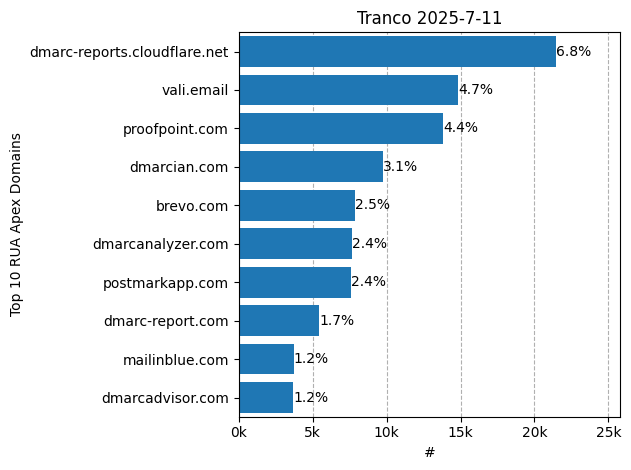

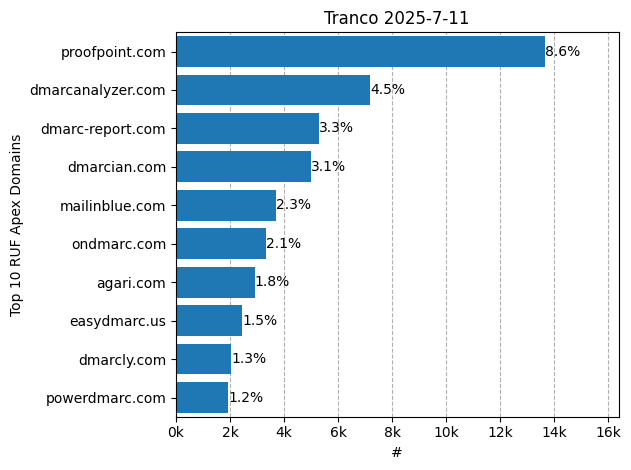

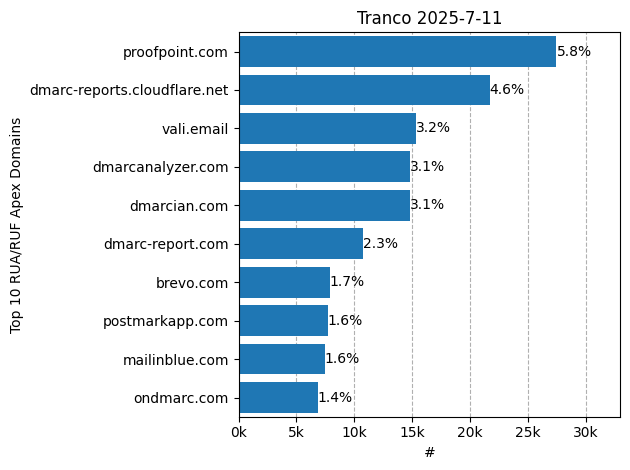

In [ ]:
def _plot_dmarc_ruaruf_tag(top_n, domain_tag, ylabel, start_date):
    plt.figure()

    _ = plt.barh(top_n[domain_tag], top_n["count"])
    for i, (count, percent) in enumerate(zip(top_n["count"], top_n["percent"])):
        plt.text(count + 1, i, f'{percent:.1f}%', va='center', ha='left')

    plt.title(f"Tranco {start_date.year}-{start_date.month}-{start_date.day}")
    plt.xlabel("#")
    plt.ylabel(ylabel)
    plt.xlim(0, top_n["count"].max() * 1.2)
    thousands = ticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}k")
    plt.gca().xaxis.set_major_formatter(thousands)
    plt.gca().set_axisbelow(True)
    plt.gca().xaxis.grid(True, linestyle='--')

    num_categories = len(top_n)
    plt.ylim(-.5, num_categories - .5)  # Minimal padding
    plt.gca().invert_yaxis()  # To show highest values at top

    plt.tight_layout()
    plt.savefig(f"figures/{domain_tag}_proportion.pdf", bbox_inches='tight')
    plt.show()


_plot_dmarc_ruaruf_tag(aggr_rua_pdf.head(10), "rua_apex_domain", "Top 10 rua Apex Domains", start_date)
_plot_dmarc_ruaruf_tag(aggr_ruf_pdf.head(10), "ruf_apex_domain", "Top 10 ruf Apex Domains", start_date)
_plot_dmarc_ruaruf_tag(aggr_rua_ruf_pdf.head(10), "rua_ruf_apex_domain", "Top 10 rua/ruf Apex Domains", start_date)

top 10 are all organisations (no individuals/admins)   
dmarc-report.com - doesn't exist  
postmarkapp.com - email delivery company  
cloudflare - cdn with email sec service  
the rest are email security companies.  

related work: proofpoint.com, reportdmarc.nl, mailingblue.com, agari.com, dmarcanalyzer.com, 163.com, dmarcian.com, dmarc-report.com, amazon.com, cloudflare.net, vali.email, gmail.com, secureserver.net, cisco.com, dmarcadvisor.com, domeneshop.no, postmarkapp.com, ondmarc.com, barracudanetworks.com, microhost.pl  